SetUp

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!ls -al /content/drive/MyDrive/Data/B5_C2_D1_4492_4499_trimmed_resized/

total 353540
-rw------- 1 root root 362003755 Sep  9 07:38 B5_C2_D1_4492_4499_trimmed_resized.mp4
drwx------ 2 root root      4096 Sep  9 07:36 chunks
drwx------ 2 root root      4096 Sep  9 09:32 frames
drwx------ 2 root root      4096 Sep  9 09:26 .ipynb_checkpoints
drwx------ 2 root root      4096 Sep 18 11:08 sam_outputs_csv
drwx------ 2 root root      4096 Sep 18 11:08 sam_outputs_videos


In [28]:

!cp -r /content/drive/MyDrive/Data/B5_C2_D1_4492_4499_trimmed_resized /content/

Extract Frame

In [29]:
import cv2
import os

# Define video file path and output directory
video_file_path = '/content/B5_C2_D1_4492_4499_trimmed_resized/chunks/chunk_1_undist.mp4'
output_directory = '/content/B5_C2_D1_4492_4499_trimmed_resized/frames/'

# Create output directory if it doesn't exist
if not os.path.exists(output_directory):
    os.makedirs(output_directory)

# Initialize video capture
cap = cv2.VideoCapture(video_file_path)

# Check if video file was opened successfully
if not cap.isOpened():
    print("Error opening video file")
else:
    frame_count = 0
    while cap.isOpened() and frame_count < 3:
        ret, frame = cap.read()
        if not ret:
            break
        # Save frame to output directory
        cv2.imwrite(os.path.join(output_directory, f'frame_{frame_count}_undist.jpg'), frame)
        frame_count += 1
    cap.release()
    cv2.destroyAllWindows()

In [30]:
import cv2
import os

# Define video file path and output directory
video_file_path = '/content/B5_C2_D1_4492_4499_trimmed_resized/B5_C2_D1_4492_4499_trimmed_resized.mp4'
output_directory = '/content/B5_C2_D1_4492_4499_trimmed_resized/frames/'

# Create output directory if it doesn't exist
if not os.path.exists(output_directory):
    os.makedirs(output_directory)

# Initialize video capture
cap = cv2.VideoCapture(video_file_path)

# Check if video file was opened successfully
if not cap.isOpened():
    print("Error opening video file")
else:
    frame_count = 0
    while cap.isOpened() and frame_count < 3:
        ret, frame = cap.read()
        if not ret:
            break
        # Save frame to output directory
        cv2.imwrite(os.path.join(output_directory, f'frame_{frame_count}.jpg'), frame)
        frame_count += 1
    cap.release()
    cv2.destroyAllWindows()

In [34]:
# !cp -r /content/B5_C2_D1_4492_4499_trimmed_resized/frames/. /content/drive/MyDrive/Data/B5_C2_D1_4492_4499_trimmed_resized/frames/

In [ ]:
!ls -al /content/B5_C2_D1_4492_4499_trimmed_resized/frames

Visual Examining Lens Corection

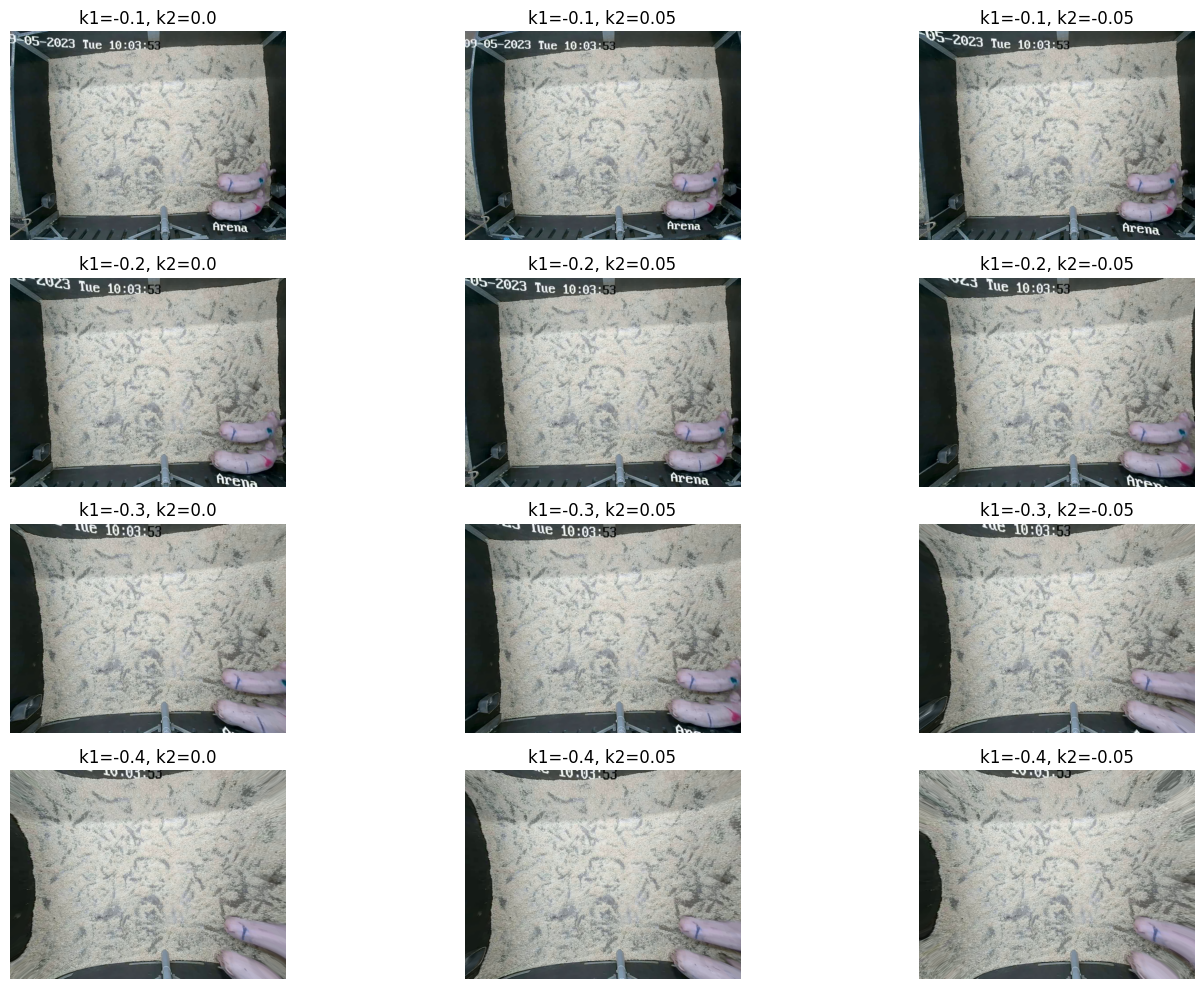

In [31]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# --- Load your image ---
img_path = "/content/B5_C2_D1_4492_4499_trimmed_resized/frames/frame_0.jpg"
img = cv2.imread(img_path)

# --- Camera intrinsic matrix (approximate, adjust if needed) ---
h, w = img.shape[:2]
fx, fy = 800, 800
cx, cy = w // 2, h // 2
K = np.array([[fx, 0, cx],
              [0, fy, cy],
              [0,  0,  1]], dtype=np.float32)

def undistort_image(img, k1=-0.25, k2=0.05, k3=0.0, p1=0.0, p2=0.0):
    """Apply distortion correction with given parameters."""
    dist = np.array([k1, k2, p1, p2, k3], dtype=np.float32)
    return cv2.undistort(img, K, dist, None, K)

# --- Try multiple values of k1 and k2 ---
k1_values = [-0.1, -0.2, -0.3, -0.4]
k2_values = [0.0, 0.05, -0.05]

fig, axes = plt.subplots(len(k1_values), len(k2_values), figsize=(15, 10))
for i, k1 in enumerate(k1_values):
    for j, k2 in enumerate(k2_values):
        undist = undistort_image(img, k1=k1, k2=k2)
        axes[i, j].imshow(cv2.cvtColor(undist, cv2.COLOR_BGR2RGB))
        axes[i, j].set_title(f"k1={k1}, k2={k2}")
        axes[i, j].axis("off")

plt.tight_layout()
plt.show()

Confirming BBX

✅ Undistorted image saved to: /content/B5_C2_D1_4492_4499_trimmed_resized/undist/frame_00001_undist.jpg
✅ Undistorted image with arena box saved to: /content/B5_C2_D1_4492_4499_trimmed_resized/undist/frame_00001_undist_box.jpg


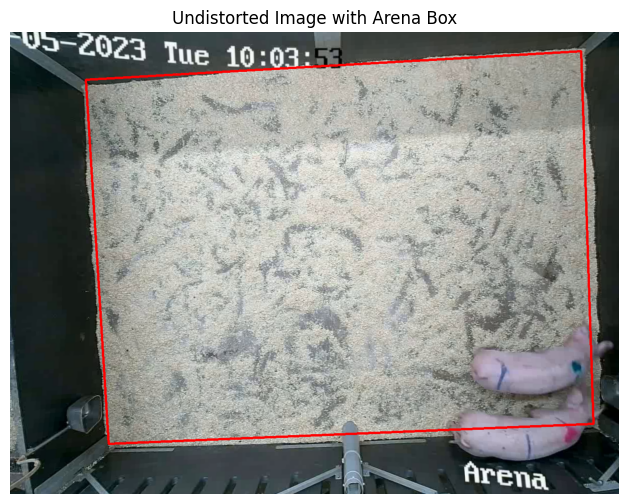

In [32]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# --- Load image ---
img_path = "/content/B5_C2_D1_4492_4499_trimmed_resized/frames/frame_0.jpg"
img = cv2.imread(img_path)

# --- Camera intrinsics (approximate) ---
fx, fy = 800, 800
cx, cy = img.shape[1]//2, img.shape[0]//2
K = np.array([[fx, 0, cx],
              [0, fy, cy],
              [0,  0,  1]], dtype=np.float32)

# --- Distortion coefficients ---
dist = np.array([-0.20, 0.05, 0.0, 0.0, 0.0], dtype=np.float32)

# --- Step 1: Undistort ---
undistorted = cv2.undistort(img, K, dist, None, K)

# === Save undistorted image ===
out_dir = "/content/B5_C2_D1_4492_4499_trimmed_resized/undist"
os.makedirs(out_dir, exist_ok=True)
out_path = os.path.join(out_dir, "frame_00001_undist.jpg")
cv2.imwrite(out_path, undistorted)
print(f"✅ Undistorted image saved to: {out_path}")

# --- Step 2: Draw rectangle (arena corners) ---
arena_corners = np.array([
    [159,100],
    [1200,40],
    [1226,824],
    [207,866]
], dtype=np.int32)

# Draw polygon on undistorted image
undist_with_box = undistorted.copy()
cv2.polylines(undist_with_box, [arena_corners], isClosed=True, color=(0,0,255), thickness=4)

# === Save image with box ===
box_path = os.path.join(out_dir, "frame_00001_undist_box.jpg")
cv2.imwrite(box_path, undist_with_box)
print(f"✅ Undistorted image with arena box saved to: {box_path}")

# --- Show result ---
plt.figure(figsize=(12,6))
plt.imshow(cv2.cvtColor(undist_with_box, cv2.COLOR_BGR2RGB))
plt.title("Undistorted Image with Arena Box")
plt.axis("off")
plt.show()


YOLO + SAM Workflow for RealTIme Videos

1. Split Large Videos into Chunks
To accommodate 15 GB GPU memory, long videos are split into smaller chunks of approximately 750 frames each. The chunking process involves:
  - Running YOLO detection on each frame
  - Skipping frames with other than exactly 2 pigs detected
  - Skipping frames with IoU ≥ 0.3 with the previous frame
  - Marking the start of a new chunk and writing frames until the chunk size is reached
  - Correct Distortion: Apply distortion correction to each chunk cv2.undistort.

2. Process Each Chunk
Each chunk is processed as follows:
  - Load Models: Load YOLO and SAM models.
  - Define Arena: Define the arena boundaries and compute the pixel-to-meter conversion factor based on a 5x5 meter square.

For each frame in the chunk:
  - With given arena, previous, current frame Homography to Correct ground geomatry for accurate distance in meters.
  - YOLO Detection: Run YOLO on the first frame to detect pigs.
  - SAM Tracking: Use SAM to track pigs across frames.
  - Frame Processing:
    - Overlay pig masks
    - Draw bounding boxes, ID labels, and centers.
    - Convert pixel positions to meters (5x5 Mapping)
    - Update and display distance traveled (white text).
    - Calculate Speed, Accelaration based on these aggression of each pig shown in top right.
    - Add a watermark (YOLO/SAM).
  - Save Output: Save the processed frame to the output video and the first 10 frames to a preview video.
  - Save: Save the frame_id, pig_no, xm, ym, (midpoint), distance traveled to a CSV file.

In [36]:
!pip install -qU ultralytics

!gdown https://drive.google.com/uc?id=1YTbpI-m27oDJdGivKA1x01MA37Kv8_5- -O /content/pigs-yolov8-weights.zip
!unzip /content/pigs-yolov8-weights.zip -d /content

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 26.0 MB/s eta 0:00:00
Downloading...
From (original): https://drive.google.com/uc?id=1YTbpI-m27oDJdGivKA1x01MA37Kv8_5-
From (redirected): https://drive.google.com/uc?id=1YTbpI-m27oDJdGivKA1x01MA37Kv8_5-&confirm=t&uuid=e529c7de-60f5-4cee-83d2-8d00c82c2b02
To: /content/pigs-yolov8-weights.zip
100% 169M/169M [00:04<00:00, 40.5MB/s]
Archive:  /content/pigs-yolov8-weights.zip
  inflating: /content/v9/labels.jpg  
  inflating: /content/v9/train_batch5040.jpg  
  inflating: /content/v9/results.png  
  inflating: /content/v9/confusion_matrix_normalized.png  
  inflating: /content/v9/confusion_matrix.png  
  inflating: /content/v9/train_batch1.jpg  
  inflating: /content/v9/PR_curve.png  
  inflating: /content/v9/P_curve.png  
  inflating: /content/v9/events.out.tfevents.1718383799.Manzar-PC.2885.0  
  inflating: /content/v9/val_batch1_labels.jpg  
  inflating: /content/v9/train_batch0.jpg  
  inflating: /content/v9/train_batch5042.jpg  
  

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
🎥 Video info: 1280x972 @ 12 FPS
📊 Total frames: 5394

▶️ Started new chunk 1: /content/B5_C2_D1_4492_4499_trimmed_resized/chunks/chunk_1.mp4
📌 Start frame: 1
🐷 Pigs detected: 2
   Pig 1 BBX: (948, 596), (1198, 747)
   Pig 2 BBX: (904, 719), (1181, 866)
🔗 IoU between pigs: 0.092


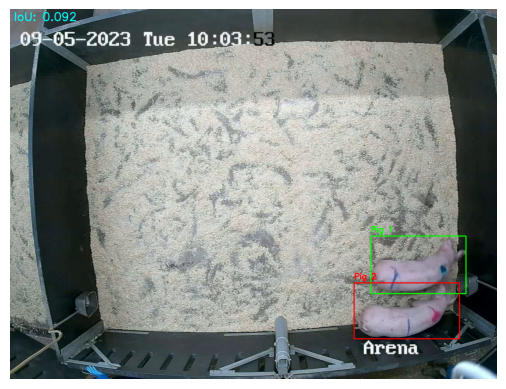

Chunk 1: 100%|██████████| 750/750 [00:36<00:00, 20.37frame/s]


🏁 End frame: 833


▶️ Started new chunk 2: /content/B5_C2_D1_4492_4499_trimmed_resized/chunks/chunk_2.mp4
📌 Start frame: 834
🐷 Pigs detected: 2
   Pig 1 BBX: (450, 67), (791, 193)
   Pig 2 BBX: (392, 69), (524, 363)
🔗 IoU between pigs: 0.127


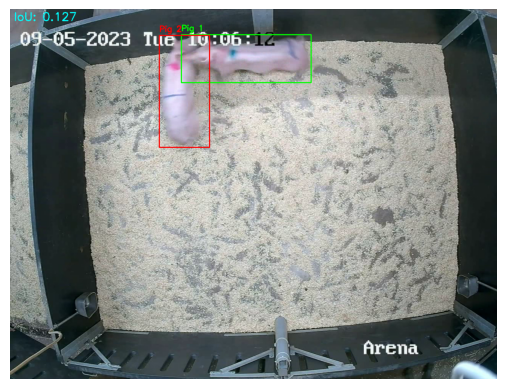

Chunk 2: 100%|██████████| 750/750 [00:38<00:00, 19.68frame/s]


🏁 End frame: 1658


▶️ Started new chunk 3: /content/B5_C2_D1_4492_4499_trimmed_resized/chunks/chunk_3.mp4
📌 Start frame: 1659
🐷 Pigs detected: 2
   Pig 1 BBX: (1004, 707), (1202, 854)
   Pig 2 BBX: (806, 622), (1031, 794)
🔗 IoU between pigs: 0.035


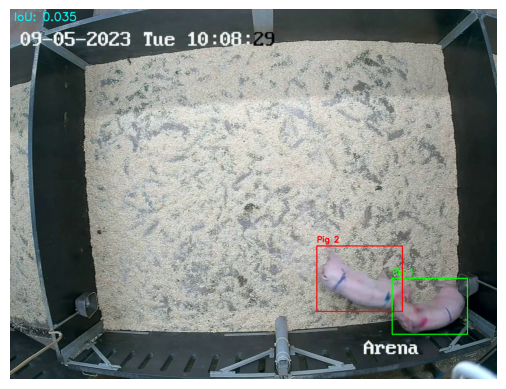

Chunk 3: 100%|██████████| 750/750 [00:42<00:00, 17.80frame/s]


🏁 End frame: 2622


▶️ Started new chunk 4: /content/B5_C2_D1_4492_4499_trimmed_resized/chunks/chunk_4.mp4
📌 Start frame: 2623
🐷 Pigs detected: 2
   Pig 1 BBX: (589, 90), (819, 371)
   Pig 2 BBX: (610, 211), (746, 482)
🔗 IoU between pigs: 0.274


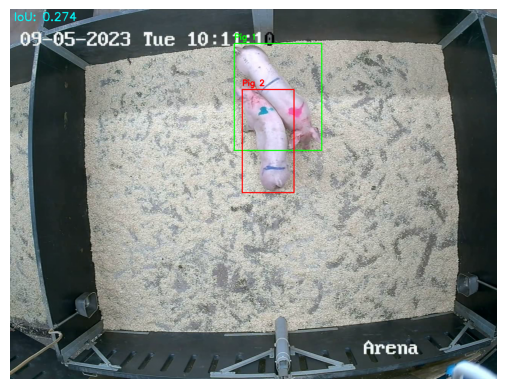

Chunk 4: 100%|██████████| 750/750 [00:40<00:00, 18.70frame/s]


🏁 End frame: 3521


▶️ Started new chunk 5: /content/B5_C2_D1_4492_4499_trimmed_resized/chunks/chunk_5.mp4
📌 Start frame: 3522
🐷 Pigs detected: 2
   Pig 1 BBX: (222, 255), (398, 551)
   Pig 2 BBX: (144, 224), (248, 512)
🔗 IoU between pigs: 0.090


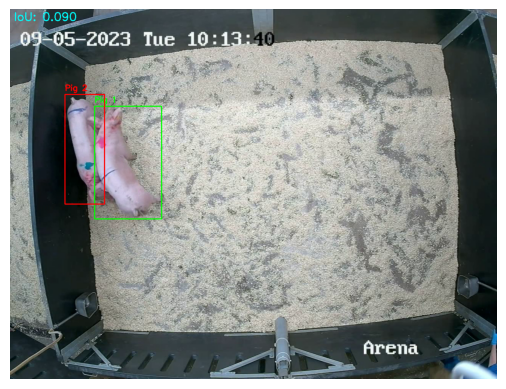

Chunk 5: 100%|██████████| 750/750 [00:49<00:00, 15.02frame/s]


🏁 End frame: 4678


▶️ Started new chunk 6: /content/B5_C2_D1_4492_4499_trimmed_resized/chunks/chunk_6.mp4
📌 Start frame: 4679
🐷 Pigs detected: 2
   Pig 1 BBX: (449, 518), (576, 817)
   Pig 2 BBX: (531, 600), (632, 914)
🔗 IoU between pigs: 0.166


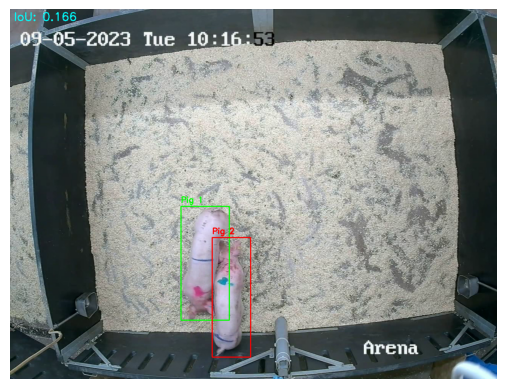

Chunk 6:  66%|██████▋   | 498/750 [00:31<00:15, 15.79frame/s]

🏁 End frame: 5394


✅ Splitting complete.


In [ ]:
import cv2
import os
from tqdm import tqdm
from ultralytics import YOLO
import matplotlib.pyplot as plt

# --- Load YOLO model ---
yolo_model = YOLO("/content/v9/weights/best.pt")  # custom pig detector

# --- Input / Output ---
video_path = "/content/B5_C2_D1_4492_4499_trimmed_resized/B5_C2_D1_4492_4499_trimmed_resized.mp4"
output_dir = "/content/B5_C2_D1_4492_4499_trimmed_resized/chunks"
os.makedirs(output_dir, exist_ok=True)
plot_dir = os.path.join(output_dir, "plots")
os.makedirs(plot_dir, exist_ok=True)

# --- Open video ---
cap = cv2.VideoCapture(video_path)

# --- Video properties ---
fps = int(cap.get(cv2.CAP_PROP_FPS))
width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

chunk_size = 750
fourcc = cv2.VideoWriter_fourcc(*"mp4v")

print(f"🎥 Video info: {width}x{height} @ {fps} FPS")
print(f"📊 Total frames: {total_frames}")

# --- IoU function ---
def iou(box1, box2):
    x1, y1, x2, y2 = box1
    x3, y3, x4, y4 = box2

    xi1, yi1 = max(x1, x3), max(y1, y3)
    xi2, yi2 = min(x2, x4), min(y2, y4)
    inter_area = max(0, xi2 - xi1) * max(0, yi2 - yi1)

    box1_area = (x2 - x1) * (y2 - y1)
    box2_area = (x4 - x3) * (y4 - y3)
    union_area = box1_area + box2_area - inter_area
    return inter_area / union_area if union_area != 0 else 0

# --- Chunk splitting with YOLO filtering ---
chunk_index = 1
frame_count = 0
out = None
pbar = None
chunk_start_frame = None

while True:
    ret, frame = cap.read()
    if not ret:
        break

    current_frame_num = int(cap.get(cv2.CAP_PROP_POS_FRAMES))

    # Run YOLO detection
    results = yolo_model(frame, verbose=False)[0]

    # Extract bounding boxes for pigs
    pigs = [box.xyxy[0].tolist() for box in results.boxes]

    # --- Check conditions ---
    if len(pigs) == 2:
        iou_value = iou(pigs[0], pigs[1])  # compute IoU for this frame
        if iou_value < 0.3:  # avoid overlapping pigs
            # Start new chunk if needed
            if frame_count % chunk_size == 0:
                if out:
                    out.release()
                    pbar.close()
                    print(f"🏁 End frame: {chunk_end_frame}\n")

                chunk_name = os.path.join(output_dir, f"chunk_{chunk_index}.mp4")
                out = cv2.VideoWriter(chunk_name, fourcc, fps, (width, height))

                # Store start frame number
                chunk_start_frame = current_frame_num
                chunk_end_frame = chunk_start_frame + chunk_size - 1

                # Print info
                print(f"\n▶️ Started new chunk {chunk_index}: {chunk_name}")
                print(f"📌 Start frame: {chunk_start_frame}")
                print(f"🐷 Pigs detected: {len(pigs)}")
                for i, bbx in enumerate(pigs, 1):
                    x1, y1, x2, y2 = map(int, bbx)
                    print(f"   Pig {i} BBX: ({x1}, {y1}), ({x2}, {y2})")
                print(f"🔗 IoU between pigs: {iou_value:.3f}")

                # --- Draw BBX and IoU on first frame ---
                frame_plot = frame.copy()
                colors = [(0,255,0),(0,0,255)]
                for i, bbx in enumerate(pigs):
                    x1, y1, x2, y2 = map(int, bbx)
                    cv2.rectangle(frame_plot, (x1, y1), (x2, y2), colors[i], 2)
                    cv2.putText(frame_plot, f'Pig {i+1}', (x1, y1-10),
                                cv2.FONT_HERSHEY_SIMPLEX, 0.7, colors[i], 2)
                cv2.putText(frame_plot, f'IoU: {iou_value:.3f}', (10,30),
                            cv2.FONT_HERSHEY_SIMPLEX, 1, (255,255,0), 2)

                # --- Save plot ---
                plot_path = os.path.join(plot_dir, f'chunk_{chunk_index}_first_frame.png')
                cv2.imwrite(plot_path, frame_plot)

                # --- Optional: display in notebook ---
                plt.imshow(cv2.cvtColor(frame_plot, cv2.COLOR_BGR2RGB))
                plt.axis('off')
                plt.show()

                pbar = tqdm(total=chunk_size, desc=f"Chunk {chunk_index}", unit="frame")
                chunk_index += 1

            out.write(frame)
            frame_count += 1
            pbar.update(1)

            # Update end frame as we go
            chunk_end_frame = current_frame_num
        else:
            continue  # Skip overlapping pigs
    else:
        continue  # Skip if not exactly 2 pigs

# --- Cleanup ---
if out:
    out.release()
    pbar.close()
    print(f"🏁 End frame: {chunk_end_frame}\n")

cap.release()
print("\n✅ Splitting complete.")

In [ ]:
import cv2
import numpy as np
import os
from tqdm import tqdm  # progress bar

# --- Folder with chunks ---
video_folder = "/content/B5_C2_D1_4492_4499_trimmed_resized/chunks"

# --- Camera intrinsics ---
fx, fy = 800, 800
dist = np.array([-0.20, 0.05, 0.0, 0.0, 0.0], dtype=np.float32)

# --- Process all .mp4 files in folder ---
video_files = sorted([f for f in os.listdir(video_folder) if f.endswith(".mp4")])

for vid_name in video_files:
    video_path = os.path.join(video_folder, vid_name)
    out_path = os.path.join(video_folder, vid_name.replace(".mp4", "_undist.mp4"))

    print(f"\n🎬 Processing {vid_name} ...")

    cap = cv2.VideoCapture(video_path)
    ret, frame = cap.read()
    if not ret:
        print(f"❌ Could not read {vid_name}, skipping.")
        cap.release()
        continue

    h, w = frame.shape[:2]
    cx, cy = w // 2, h // 2
    K = np.array([[fx, 0, cx],
                  [0, fy, cy],
                  [0,  0,  1]], dtype=np.float32)

    fps = cap.get(cv2.CAP_PROP_FPS) or 30
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    out = cv2.VideoWriter(out_path, cv2.VideoWriter_fourcc(*"mp4v"), fps, (w, h))

    # reset video
    cap.set(cv2.CAP_PROP_POS_FRAMES, 0)

    # --- Progress bar ---
    for _ in tqdm(range(total_frames), desc=f"   {vid_name}", unit="frame"):
        ret, frame = cap.read()
        if not ret:
            break
        undistorted = cv2.undistort(frame, K, dist, None, K)
        out.write(undistorted)

    cap.release()
    out.release()
    print(f"✅ Saved undistorted video: {out_path}")


In [14]:
!ls /content/B5_C2_D1_4492_4499_trimmed_resized/chunks/*_undist.mp4

/content/B5_C2_D1_4492_4499_trimmed_resized/chunks/chunk_1_undist.mp4
/content/B5_C2_D1_4492_4499_trimmed_resized/chunks/chunk_2_undist.mp4
/content/B5_C2_D1_4492_4499_trimmed_resized/chunks/chunk_3_undist.mp4
/content/B5_C2_D1_4492_4499_trimmed_resized/chunks/chunk_4_undist.mp4
/content/B5_C2_D1_4492_4499_trimmed_resized/chunks/chunk_5_undist.mp4
/content/B5_C2_D1_4492_4499_trimmed_resized/chunks/chunk_6_undist.mp4


In [40]:
# !cp -r /content/sam_outputs_csv /content/drive/MyDrive/Data/B5_C2_D1_4492_4499_trimmed_resized/
# !cp -r /content/sam_outputs_videos /content/drive/MyDrive/Data/B5_C2_D1_4492_4499_trimmed_resized/

In [ ]:
import cv2
import numpy as np
import csv
import os
import torch
from ultralytics import YOLO
from ultralytics.models.sam import SAM2VideoPredictor

# Constants
FPS = 30
BAR_WIDTH_MAX = 100
BAR_HEIGHT = 20
SPACING = 40
AGGRESSION_THRESHOLD_SPEED = 0.2
AGGRESSION_THRESHOLD_ACCEL = 0.15
DECAY_RATE = 0.05

def compute_speed_accel(history):
    """Compute speed and acceleration from history."""
    if len(history) < 3:
        return 0, 0
    (_, x_prev, y_prev), (_, x_last, y_last) = history[-2], history[-1]
    speed = np.hypot(x_last - x_prev, y_last - y_prev)
    (_, x_old, y_old), _ = history[0], history[-1]
    old_speed = np.hypot(x_prev - x_old, y_prev - y_old)
    accel = abs(speed - old_speed)
    return speed, accel

def update_aggression(pig_id, speed, accel, aggression_scores):
    """Update aggression scores based on speed and acceleration."""
    if speed > AGGRESSION_THRESHOLD_SPEED or accel > AGGRESSION_THRESHOLD_ACCEL:
        aggression_scores[pig_id] = min(10, aggression_scores.get(pig_id, 0) + 1)
    return aggression_scores

def decay_aggression(aggression_scores):
    """Decay aggression scores over time."""
    for pid in aggression_scores:
        aggression_scores[pid] = max(0, aggression_scores[pid] - DECAY_RATE)
    return aggression_scores

def draw_aggression_and_s_distance(frame, aggression_scores, distances):
    x = frame.shape[1] - 200
    y = 20
    for pig_id, aggression_score in aggression_scores.items():
        distance = distances.get(pig_id, 0)
        bar_length = int(aggression_score * 100 / 10)
        cv2.rectangle(frame, (x, y), (x + 100, y + 20), (100, 100, 100), -1)
        cv2.rectangle(frame, (x, y), (x + bar_length, y + 20), (0, 0, 255), -1)
        cv2.putText(frame, f"Pig {pig_id} | D:{distance:.2f}m", (x - 400, y + 18),
                    cv2.FONT_HERSHEY_SIMPLEX, 2.0, (255, 255, 255), 4)
        y += 50
    return frame

def order_points(pts):
    """Order points for arena corners."""
    rect = np.zeros((4, 2), dtype="float32")
    s = pts.sum(axis=1)
    diff = np.diff(pts, axis=1)
    rect[0] = pts[np.argmin(s)]
    rect[2] = pts[np.argmax(s)]
    rect[1] = pts[np.argmin(diff)]
    rect[3] = pts[np.argmax(diff)]
    return rect.astype(int)

def process_video(video_path, yolo_model, predictor, output_video_folder, output_csv_folder, arena_corners):
    """Process video for pig tracking and aggression analysis."""
    base_name = os.path.splitext(os.path.basename(video_path))[0]
    output_video_path = os.path.join(output_video_folder, f"{base_name}_processed.mp4")
    preview_path = os.path.join(output_video_folder, f"{base_name}_preview.mp4")
    output_csv_path = os.path.join(output_csv_folder, f"{base_name}_distances.csv")

    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        print(f"Could not open {video_path}")
        return

    fps = cap.get(cv2.CAP_PROP_FPS) or FPS
    frame_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    frame_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    ret, first_frame = cap.read()
    if not ret:
        print("Could not read first frame")
        cap.release()
        return

    first_rgb = cv2.cvtColor(first_frame, cv2.COLOR_BGR2RGB)
    yolo_results = yolo_model(first_rgb, verbose=False)[0]
    yolo_boxes = yolo_results.boxes.xyxy.cpu().numpy() if len(yolo_results.boxes) > 0 else []

    if len(yolo_boxes) == 0:
        print("No pigs detected.")
        cap.release()
        return

    sam_stream = predictor(source=video_path, bboxes=yolo_boxes, stream=True)

    arena_w = np.linalg.norm(np.array(arena_corners[0]) - np.array(arena_corners[1]))
    arena_h = np.linalg.norm(np.array(arena_corners[1]) - np.array(arena_corners[2]))
    meters_per_pixel = 5.0 / ((arena_w + arena_h) / 2.0)

    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    out_writer = cv2.VideoWriter(output_video_path, fourcc, fps, (frame_width, frame_height))
    preview_writer = cv2.VideoWriter(preview_path, fourcc, fps, (frame_width, frame_height))

    csv_file = open(output_csv_path, "w", newline="")
    csv_writer = csv.writer(csv_file)
    csv_writer.writerow(["Frame", "PigID", "X_m", "Y_m", "Distance_m", "Aggression"])

    pig_positions = {}
    pig_distances = {}
    pig_history = {}
    aggression_scores = {}
    preview_frames = 0

    for frame_idx, result in enumerate(sam_stream, start=1):

        frame = result.orig_img.copy()

        arena_corners_ordered = order_points(arena_corners).astype(np.int32)
        cv2.polylines(frame, [arena_corners_ordered], True, (0,0,255), 3)

        if result.masks is not None:
            for mask in result.masks.data.cpu().numpy():
                mask = (mask*255).astype(np.uint8)
                mask_colored = np.zeros_like(frame)
                mask_colored[:, :, 0] = 255
                frame[mask>0] = cv2.addWeighted(frame,0.7,mask_colored,0.3,0)[mask>0]

        if result.boxes is not None:
            for pig_id, bbox in enumerate(result.boxes.xyxy.cpu().numpy(), start=1):
                x1, y1, x2, y2 = bbox.astype(int)
                cx, cy = (x1+x2)//2, (y1+y2)//2
                pos_m = (cx*meters_per_pixel, cy*meters_per_pixel)

                if pig_id in pig_positions:
                    prev_x, prev_y = pig_positions[pig_id]
                    dist = np.linalg.norm([pos_m[0]-prev_x,pos_m[1]-prev_y])
                    pig_distances[pig_id] += dist
                else:
                    pig_distances[pig_id] = 0.0

                pig_positions[pig_id] = pos_m

                if pig_id not in pig_history:
                    pig_history[pig_id] = []
                pig_history[pig_id].append((frame_idx, pos_m[0], pos_m[1]))
                speed, accel = compute_speed_accel(pig_history[pig_id])
                aggression_scores = update_aggression(pig_id, speed, accel, aggression_scores)

                cv2.rectangle(frame,(x1,y1),(x2,y2),(255,0,0),2)
                cv2.circle(frame,(cx,cy),4,(0,255,0),-1)
                cv2.putText(frame,f"Pig {pig_id}",(x1,y1-10),
                            cv2.FONT_HERSHEY_SIMPLEX,0.6,(0,0,255),2)
                cv2.putText(frame,f"{pig_distances[pig_id]:.2f}m",(x1,y2+20),
                            cv2.FONT_HERSHEY_SIMPLEX,0.6,(255,255,255),2)

                csv_writer.writerow([frame_idx,pig_id,pos_m[0],pos_m[1],pig_distances[pig_id],aggression_scores.get(pig_id,0)])

        frame = draw_aggression_and_distance(frame, aggression_scores, pig_distances)
        aggression_scores = decay_aggression(aggression_scores)

        cv2.putText(frame,"SAM",(20,frame_height-20),
                    cv2.FONT_HERSHEY_SIMPLEX,0.8,(255,255,0),2)

        out_writer.write(frame)

        if preview_frames<10:
            preview_writer.write(frame)
            preview_frames += 1

    cap.release()
    out_writer.release()
    preview_writer.release()
    csv_file.close()
    print(f"Finished {os.path.basename(video_path)}")

def main():

    print("Loading models...")
    yolo_model = YOLO("/content/v9/weights/best.pt")
    predictor = SAM2VideoPredictor(overrides={"model": "sam2.1_b.pt"})

    video_folder = "/content/B5_C2_D1_4492_4499_trimmed_resized/chunks"
    output_video_folder = "/content/sam_outputs_videos"
    output_csv_folder = "/content/sam_outputs_csv"
    os.makedirs(output_video_folder, exist_ok=True)
    os.makedirs(output_csv_folder, exist_ok=True)

    video_files = sorted([os.path.join(video_folder, f)
                          for f in os.listdir(video_folder) if f.endswith("_undist.mp4")])

    if not video_files:
        print("No input videos found.")
        return

    print("Available videos:")
    for idx, v in enumerate(video_files, 1):
        print(f" {idx}: {os.path.basename(v)}")

    choice = int(input("Enter -1 for all, 0 for none, or 1–N for specific video: "))

    if choice == 0:
        print("No video selected. Exiting.")
        return
    elif choice == -1:
        selected_videos = video_files
    elif 1 <= choice <= len(video_files):
        selected_videos = [video_files[choice - 1]]
    else:
        print(f"Invalid choice ({choice}). Exiting.")
        return

    arena_corners = np.array([
      [153,115],
      [1207,34],
      [201,873],
      [1234,827]
    ], dtype=np.int32)

    for video_path in selected_videos:
        process_video(video_path, yolo_model, predictor,
                      output_video_folder, output_csv_folder, arena_corners)
        torch.cuda.empty_cache()
        import gc; gc.collect()

if __name__ == "__main__":
    main()

Loading models...
Available videos:
 1: chunk_1_undist.mp4
 2: chunk_2_undist.mp4
 3: chunk_3_undist.mp4
 4: chunk_4_undist.mp4
 5: chunk_5_undist.mp4
 6: chunk_6_undist.mp4
Enter -1 for all, 0 for none, or 1–N for specific video: 1

Ultralytics 8.3.197 🚀 Python-3.12.11 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
video 1/1 (frame 1/750) /content/B5_C2_D1_4492_4499_trimmed_resized/chunks/chunk_1_undist.mp4: 640x640 1 0, 1 1, 343.0ms
video 1/1 (frame 2/750) /content/B5_C2_D1_4492_4499_trimmed_resized/chunks/chunk_1_undist.mp4: 640x640 1 0, 1 1, 138.6ms
video 1/1 (frame 3/750) /content/B5_C2_D1_4492_4499_trimmed_resized/chunks/chunk_1_undist.mp4: 640x640 1 0, 1 1, 128.4ms
video 1/1 (frame 4/750) /content/B5_C2_D1_4492_4499_trimmed_resized/chunks/chunk_1_undist.mp4: 640x640 1 0, 1 1, 134.7ms
video 1/1 (frame 5/750) /content/B5_C2_D1_4492_4499_trimmed_resized/chunks/chunk_1_undist.mp4: 640x640 1 0, 1 1, 145.9ms
video 1/1 (frame 6/750) /content/B5_C2_D1_4492_4499_trimmed_resized/chunks/chu

BIRD EYE-View

Two Different Concepts

**1. Camera Intrinsic Matrix (K)**

* Creates a 3x3 matrix describing internal camera parameters
* Formula:
$$
K = \begin{bmatrix}
fx & 0 & cx \\
0 & fy & cy \\
0 & 0 & 1
\end{bmatrix}
$$
* Includes focal lengths ($f_x$, $f_y$) and principal point coordinates ($c_x$, $c_y$)
* Used in:
	+ Camera Calibration
	+ 3D Reconstruction
	+ Image Undistortion

***NO Camera Paramters done by Random Sampling***

<br>

**2. Homography Estimation**

* Estimates a 3x3 matrix describing perspective transformation between two images
* Formula:
$$
H = \begin{bmatrix}
h_{11} & h_{12} & h_{13} \\
h_{21} & h_{22} & h_{23} \\
h_{31} & h_{32} & h_{33}
\end{bmatrix}
$$
* $x' = \frac{h_{11}x + h_{12}y + h_{13}}{h_{31}x + h_{32}y + h_{33}}$
* $y' = \frac{h_{21}x + h_{22}y + h_{23}}{h_{31}x + h_{32}y + h_{33}}$
* Uses ORB feature detection and RANSAC
* Used in:
	+ Image Registration
	+ Image Stitching
	+ Object Tracking
	+ Augmented Reality

**Key differences:**

* **Purpose:** Camera intrinsic matrix vs. homography matrix
* **Input:** Camera parameters vs. two images
* **Output:** Camera intrinsic matrix vs. homography matrix

In [38]:
import cv2
import numpy as np
import csv
import os
import torch
from ultralytics import YOLO
from ultralytics.models.sam import SAM2VideoPredictor

# Constants
FPS = 30
BAR_WIDTH_MAX = 50  # Reduced aggression bar width
BAR_HEIGHT = 10    # Reduced aggression bar height
SPACING = 30       # Reduced spacing for aggression bars
AGGRESSION_THRESHOLD_SPEED = 0.2
AGGRESSION_THRESHOLD_ACCEL = 0.15
DECAY_RATE = 0.05

def compute_speed_accel(history):
    """Compute speed and acceleration from history."""
    if len(history) < 3:
        return 0, 0
    (_, x_prev, y_prev), (_, x_last, y_last) = history[-2], history[-1]
    speed = np.hypot(x_last - x_prev, y_last - y_prev)
    (_, x_old, y_old), _ = history[0], history[-1]
    old_speed = np.hypot(x_prev - x_old, y_prev - y_old)
    accel = abs(speed - old_speed)

    return speed, accel

def update_aggression(pig_id, speed, accel, aggression_scores):
    """Update aggression scores based on speed and acceleration."""
    if speed > AGGRESSION_THRESHOLD_SPEED or accel > AGGRESSION_THRESHOLD_ACCEL:
        aggression_scores[pig_id] = min(10, aggression_scores.get(pig_id, 0) + 1)

    return aggression_scores

def decay_aggression(aggression_scores):
    """Decay aggression scores over time."""
    for pid in aggression_scores:
        aggression_scores[pid] = max(0, aggression_scores[pid] - DECAY_RATE)

    return aggression_scores

def draw_aggression_and_distance(frame, aggression_scores, distances):
    x = frame.shape[1] - 150  # Adjusted for smaller bar
    y = 20
    for pig_id, aggression_score in aggression_scores.items():
        distance = distances.get(pig_id, 0)
        bar_length = int(aggression_score * BAR_WIDTH_MAX / 10)
        cv2.rectangle(frame, (x, y), (x + BAR_WIDTH_MAX, y + BAR_HEIGHT), (100, 100, 100), -1)
        cv2.rectangle(frame, (x, y), (x + bar_length, y + BAR_HEIGHT), (0, 0, 255), -1)
        cv2.putText(frame, f"Pig {pig_id} | D:{distance:.2f}m", (x - 300, y + BAR_HEIGHT // 2 + 5),
                    cv2.FONT_HERSHEY_SIMPLEX, 1.0, (255, 255, 255), 2)  # Reduced font scale
        y += SPACING

    return frame

def order_points(pts):
    """Order points for arena corners."""
    rect = np.zeros((4, 2), dtype="float32")
    s = pts.sum(axis=1)
    diff = np.diff(pts, axis=1)
    rect[0] = pts[np.argmin(s)]
    rect[2] = pts[np.argmax(s)]
    rect[1] = pts[np.argmin(diff)]
    rect[3] = pts[np.argmax(diff)]

    return rect.astype(int)

def estimate_homography(prev_frame, curr_frame):
    """Estimate homography between two frames using ORB and RANSAC."""
    orb = cv2.ORB_create()
    kp1, des1 = orb.detectAndCompute(prev_frame, None)
    kp2, des2 = orb.detectAndCompute(curr_frame, None)

    if des1 is None or des2 is None:
        return None  # Return None if no descriptors are found

    bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
    matches = bf.match(des1, des2)
    matches = sorted(matches, key=lambda x: x.distance)

    if len(matches) < 4:
        return None  # Not enough matches for homography

    src_pts = np.float32([kp1[m.queryIdx].pt for m in matches]).reshape(-1, 1, 2)
    dst_pts = np.float32([kp2[m.trainIdx].pt for m in matches]).reshape(-1, 1, 2)

    H, _ = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0)

    return H

def transform_bbox(bbox, H):
    """Transform bounding box coordinates using homography matrix."""
    x1, y1, x2, y2 = bbox
    corners = np.float32([[x1, y1], [x2, y1], [x2, y2], [x1, y2]]).reshape(-1, 1, 2)
    transformed_corners = cv2.perspectiveTransform(corners, H)
    x1_t, y1_t = np.min(transformed_corners, axis=0).ravel()
    x2_t, y2_t = np.max(transformed_corners, axis=0).ravel()

    return np.array([x1_t, y1_t, x2_t, y2_t])  # Return NumPy array

def process_video(video_path, yolo_model, predictor, output_video_folder, output_csv_folder, arena_corners):
    """Process video for pig tracking and aggression analysis with homography."""
    base_name = os.path.splitext(os.path.basename(video_path))[0]
    output_video_path = os.path.join(output_video_folder, f"{base_name}_processed.mp4")
    preview_path = os.path.join(output_video_folder, f"{base_name}_preview.mp4")
    output_csv_path = os.path.join(output_csv_folder, f"{base_name}_distances.csv")

    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        print(f"Could not open {video_path}")
        return

    fps = cap.get(cv2.CAP_PROP_FPS) or FPS
    frame_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    frame_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    ret, first_frame = cap.read()
    if not ret:
        print("Could not read first frame")
        cap.release()
        return

    first_rgb = cv2.cvtColor(first_frame, cv2.COLOR_BGR2RGB)
    yolo_results = yolo_model(first_rgb, verbose=False)[0]
    yolo_boxes = yolo_results.boxes.xyxy.cpu().numpy() if len(yolo_results.boxes) > 0 else []

    if len(yolo_boxes) == 0:
        print("No pigs detected.")
        cap.release()
        return

    # Initialize homography reference frame
    ref_frame = cv2.cvtColor(first_frame, cv2.COLOR_BGR2GRAY)
    ref_corners = order_points(arena_corners).astype(np.float32)
    ref_arena = np.float32([[0, 0], [frame_width, 0], [frame_width, frame_height], [0, frame_height]])
    H_ref, _ = cv2.findHomography(ref_corners, ref_arena, cv2.RANSAC, 5.0)

    sam_stream = predictor(source=video_path, bboxes=yolo_boxes, stream=True)

    arena_w = np.linalg.norm(np.array(arena_corners[0]) - np.array(arena_corners[1]))
    arena_h = np.linalg.norm(np.array(arena_corners[1]) - np.array(arena_corners[2]))
    meters_per_pixel = 5.0 / ((arena_w + arena_h) / 2.0)

    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    out_writer = cv2.VideoWriter(output_video_path, fourcc, fps, (frame_width, frame_height))
    preview_writer = cv2.VideoWriter(preview_path, fourcc, fps, (frame_width, frame_height))

    csv_file = open(output_csv_path, "w", newline="")
    csv_writer = csv.writer(csv_file)
    csv_writer.writerow(["Frame", "PigID", "X_m", "Y_m", "Distance_m", "Aggression"])

    pig_positions = {}
    pig_distances = {}
    pig_history = {}
    aggression_scores = {}
    preview_frames = 0
    prev_frame = ref_frame

    for frame_idx, result in enumerate(sam_stream, start=1):
        frame = result.orig_img.copy()
        frame_gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

        # Estimate homography between current frame and reference frame
        H = estimate_homography(prev_frame, frame_gray)
        if H is None:
            H = np.eye(3)  # Fallback to identity matrix if homography estimation fails

        # Transform frame to reference frame
        frame_warped = cv2.warpPerspective(frame, H_ref @ H, (frame_width, frame_height))

        # Removed: cv2.polylines for arena corners

        if result.masks is not None:
            pig_colors = {1: (238, 84, 144), 2: (0, 0, 255)}  # Pink for pig 1, Blue for pig 2
            for i, (mask, bbox, pig_id) in enumerate(zip(result.masks.data.cpu().numpy(), result.boxes.xyxy.cpu().numpy(), range(1, len(result.boxes.xyxy.cpu().numpy()) + 1))):
                mask = (mask * 255).astype(np.uint8)
                mask_warped = cv2.warpPerspective(mask, H_ref @ H, (frame_width, frame_height))
                mask_colored = np.zeros_like(frame_warped)
                mask_colored[:, :, 0] = pig_colors[pig_id][2]  # B
                mask_colored[:, :, 1] = pig_colors[pig_id][1]  # G
                mask_colored[:, :, 2] = pig_colors[pig_id][0]  # R
                frame_warped[mask_warped > 0] = cv2.addWeighted(frame_warped, 0.7, mask_colored, 0.3, 0)[mask_warped > 0]

        if result.boxes is not None:
            for pig_id, bbox in enumerate(result.boxes.xyxy.cpu().numpy(), start=1):

                # Transform bounding box to reference frame
                bbox_transformed = transform_bbox(bbox, H_ref @ H)
                x1, y1, x2, y2 = bbox_transformed.astype(int)
                cx, cy = (x1 + x2) // 2, (y1 + y2) // 2
                pos_m = (cx * meters_per_pixel, cy * meters_per_pixel)

                if pig_id in pig_positions:
                    prev_x, prev_y = pig_positions[pig_id]
                    dist = np.linalg.norm([pos_m[0] - prev_x, pos_m[1] - prev_y])
                    pig_distances[pig_id] += dist
                else:
                    pig_distances[pig_id] = 0.0

                pig_positions[pig_id] = pos_m

                if pig_id not in pig_history:
                    pig_history[pig_id] = []
                pig_history[pig_id].append((frame_idx, pos_m[0], pos_m[1]))
                speed, accel = compute_speed_accel(pig_history[pig_id])
                aggression_scores = update_aggression(pig_id, speed, accel, aggression_scores)

                cv2.rectangle(frame_warped, (x1, y1), (x2, y2), (0, 165, 255), 2)
                cv2.circle(frame_warped, (cx, cy), 4, (0, 255, 0), -1)
                cv2.putText(frame_warped, f"Pig {pig_id}", (x1, y1 - 10),
                            cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2)
                cv2.putText(frame_warped, f"{pig_distances[pig_id]:.2f}m", (x1, y2 + 15),
                            cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2)

                csv_writer.writerow([frame_idx, pig_id, pos_m[0], pos_m[1], pig_distances[pig_id], aggression_scores.get(pig_id, 0)])

        frame_warped = draw_aggression_and_distance(frame_warped, aggression_scores, pig_distances)
        aggression_scores = decay_aggression(aggression_scores)

        cv2.putText(frame_warped, "SAM", (20, frame_height - 20),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 255, 0), 2)

        out_writer.write(frame_warped)

        if preview_frames < 10:
            preview_writer.write(frame_warped)
            preview_frames += 1

        prev_frame = frame_gray

    cap.release()
    out_writer.release()
    preview_writer.release()
    csv_file.close()
    print(f"Finished {os.path.basename(video_path)}")

def main():
    print("Loading models...")
    yolo_model = YOLO("/content/v9/weights/best.pt")
    predictor = SAM2VideoPredictor(overrides={"model": "sam2.1_b.pt"})

    video_folder = "/content/B5_C2_D1_4492_4499_trimmed_resized/chunks"
    output_video_folder = "/content/sam_outputs_videos"
    output_csv_folder = "/content/sam_outputs_csv"
    os.makedirs(output_video_folder, exist_ok=True)
    os.makedirs(output_csv_folder, exist_ok=True)

    video_files = sorted([os.path.join(video_folder, f)
                          for f in os.listdir(video_folder) if f.endswith("_undist.mp4")])

    if not video_files:
        print("No input videos found.")
        return

    print("Available videos:")
    for idx, v in enumerate(video_files, 1):
        print(f" {idx}: {os.path.basename(v)}")

    choice = int(input("Enter -1 for all, 0 for none, or 1–N for specific video: "))

    if choice == 0:
        print("No video selected. Exiting.")
        return
    elif choice == -1:
        selected_videos = video_files
    elif 1 <= choice <= len(video_files):
        selected_videos = [video_files[choice - 1]]
    else:
        print(f"Invalid choice ({choice}). Exiting.")
        return

    arena_corners = np.array([
        [153, 115],
        [1207, 34],
        [201, 873],
        [1234, 827]
    ], dtype=np.int32)

    for video_path in selected_videos:
        process_video(video_path, yolo_model, predictor,
                      output_video_folder, output_csv_folder, arena_corners)
        torch.cuda.empty_cache()
        import gc; gc.collect()

if __name__ == "__main__":
    main()

Loading models...
Available videos:
 1: chunk_1_undist.mp4
 2: chunk_2_undist.mp4
 3: chunk_3_undist.mp4
 4: chunk_4_undist.mp4
 5: chunk_5_undist.mp4
 6: chunk_6_undist.mp4
Enter -1 for all, 0 for none, or 1–N for specific video: 1

Ultralytics 8.3.202 🚀 Python-3.12.11 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
video 1/1 (frame 1/750) /content/B5_C2_D1_4492_4499_trimmed_resized/chunks/chunk_1_undist.mp4: 640x640 1 0, 1 1, 296.6ms
video 1/1 (frame 2/750) /content/B5_C2_D1_4492_4499_trimmed_resized/chunks/chunk_1_undist.mp4: 640x640 1 0, 1 1, 145.1ms
video 1/1 (frame 3/750) /content/B5_C2_D1_4492_4499_trimmed_resized/chunks/chunk_1_undist.mp4: 640x640 1 0, 1 1, 133.5ms
video 1/1 (frame 4/750) /content/B5_C2_D1_4492_4499_trimmed_resized/chunks/chunk_1_undist.mp4: 640x640 1 0, 1 1, 143.4ms
video 1/1 (frame 5/750) /content/B5_C2_D1_4492_4499_trimmed_resized/chunks/chunk_1_undist.mp4: 640x640 1 0, 1 1, 152.5ms
video 1/1 (frame 6/750) /content/B5_C2_D1_4492_4499_trimmed_resized/chunks/chu